## Implementation of DecisionTree

## Importing Required Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, confusion_matrix,
    roc_auc_score, roc_curve, classification_report, f1_score, precision_recall_curve, average_precision_score
)
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')

In [4]:
data = pd.read_csv('data.csv')
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Data cleaning and formatting

In [5]:
# Removing unecessary columns from the dataset
data = data.drop(['id','Unnamed: 32'],axis=1)
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
# Checking for null values.
data.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [7]:
# Converting the target column to 0s and 1s for ease of prediction. Splitting the data into X and y
X = data.drop("diagnosis", axis=1)
y = data["diagnosis"].map({"M": 1, "B": 0}) 

## Insights on the data

In [8]:
# Printing the correlation of the features with the label
corr = pd.concat([X, y], axis=1).corr()["diagnosis"].sort_values(ascending=False)
print("Correlation with target:\n", corr)

Correlation with target:
 diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
sy

In [9]:
# Prints the number of 0 (Benign) cases and 1 (Malignant) cases
print("Class counts:")
print(y.value_counts())

Class counts:
diagnosis
0    357
1    212
Name: count, dtype: int64


## Splitting the data

In [10]:
# Spliting the data into train, validation and test data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

## Feature scaling

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

## Decision Tree implementation

In [12]:
decision_tree_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
}

DecisionTree = DecisionTreeClassifier(random_state=42)
decision_tree_grid = GridSearchCV(DecisionTree, decision_tree_params, cv=5, scoring="f1")
decision_tree_grid.fit(X_train, y_train)

print("Best Decision Tree params:", decision_tree_grid.best_params_)
decsion_tree_best = decision_tree_grid.best_estimator_

Best Decision Tree params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 10}


## Results of the decision tree

In [13]:
decision_tree_results = []

for crit in decision_tree_params["criterion"]:
    for depth in decision_tree_params["max_depth"]:
        for minsplit in decision_tree_params["min_samples_split"]:
            
            model = DecisionTreeClassifier(
                criterion=crit,
                max_depth=depth,
                min_samples_split=minsplit,
                random_state=42
            )

            model.fit(X_train, y_train)
            preds = model.predict(X_valid)
            probs = model.predict_proba(X_valid)[:, 1]

            accuracy = round(accuracy_score(y_valid, preds), 2)

            # Malignant class (1)
            precision_M = round(precision_score(y_valid, preds, pos_label=1), 2)
            recall_M = round(recall_score(y_valid, preds, pos_label=1), 2)
            f1_M = round(f1_score(y_valid, preds, pos_label=1), 2)
            
            # Benign class (0)
            precision_B = round(precision_score(y_valid, preds, pos_label=0), 2)
            recall_B = round(recall_score(y_valid, preds, pos_label=0), 2)
            f1_B = round(f1_score(y_valid, preds, pos_label=0), 2)
            
            auc = round(roc_auc_score(y_valid, probs), 2)
            cm = confusion_matrix(y_valid, preds)

            decision_tree_results.append({
            "criterion": crit,
            "max_depth": depth,
            "min_samples_split": minsplit,
            "Accuracy": accuracy,
            "Precision(M)": precision_M,
            "Recall(M)": recall_M,
            "F1(M)": f1_M,
            "Precision(B)": precision_B,
            "Recall(B)": recall_B,
            "F1(B)": f1_B,
            "AUC": auc,
            "Confusion Matrix": cm
                })


In [14]:
decision_tree_results = pd.DataFrame(decision_tree_results)
results_decision_tree = decision_tree_results.sort_values(by="F1(M)", ascending=False)
print(results_decision_tree)

   criterion  max_depth  min_samples_split  Accuracy  Precision(M)  Recall(M)  \
15   entropy        5.0                  2      0.96          0.97       0.91   
3       gini        5.0                  2      0.95          0.97       0.88   
16   entropy        5.0                  5      0.95          0.97       0.88   
6       gini       10.0                  2      0.94          0.95       0.88   
9       gini        NaN                  2      0.94          0.95       0.88   
2       gini        3.0                 10      0.94          0.97       0.86   
1       gini        3.0                  5      0.94          0.97       0.86   
0       gini        3.0                  2      0.94          0.97       0.86   
14   entropy        3.0                 10      0.94          0.97       0.86   
13   entropy        3.0                  5      0.94          0.97       0.86   
4       gini        5.0                  5      0.94          0.97       0.86   
12   entropy        3.0     

## Confusion Matrix 


====== Decision Tree ======
Accuracy: 0.94
AUC: 0.95
Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95        72
           1       1.00      0.83      0.91        42

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114

Confusion Matrix:
 [[72  0]
 [ 7 35]]


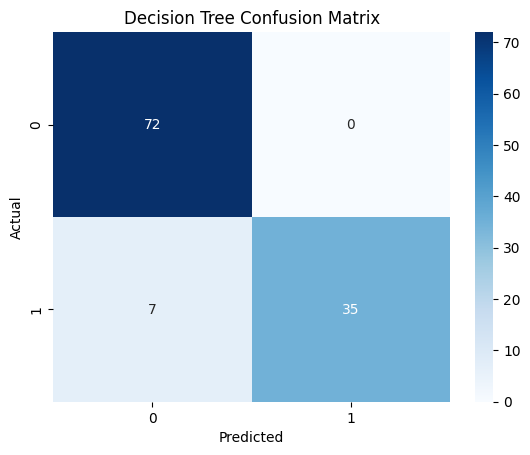

In [15]:
models = {"Decision Tree": decsion_tree_best}

for name, model in models.items():
    y_pred = model.predict(X_test)

    print("\n======", name, "======")
    print("Accuracy:", round(accuracy_score(y_test, y_pred),2))
    print("AUC:", round(roc_auc_score(y_test, model.predict_proba(X_test)[:,1]),2))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## ROC_AUC curve

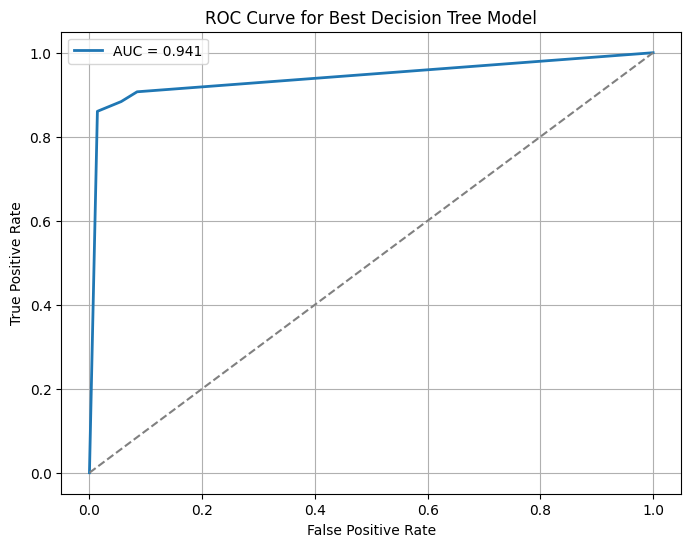

In [16]:
# ROC_AUC curve for the best decision tree model

y_prob = decsion_tree_best.predict_proba(X_valid)[:, 1]

fpr, tpr, _ = roc_curve(y_valid, y_prob)
auc = roc_auc_score(y_valid, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", linewidth=2)
plt.plot([0,1],[0,1],'--', color='gray')
plt.title("ROC Curve for Best Decision Tree Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

## Learning curve

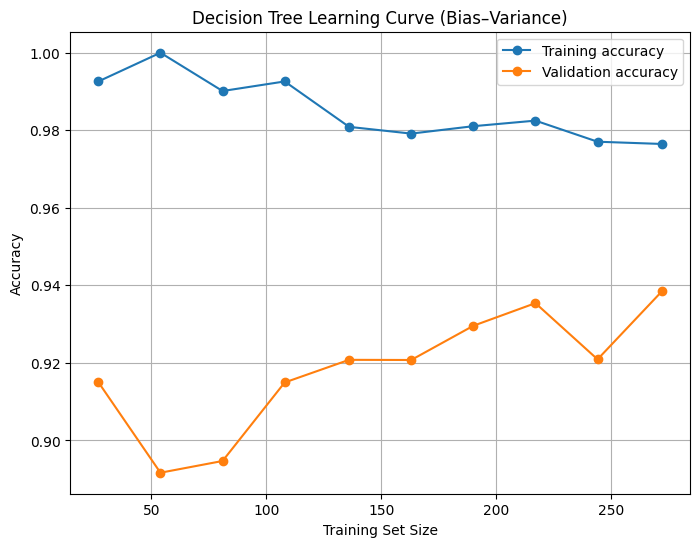

In [17]:
# Learning curve for bias variance analysis
def plot_learning_curve(model, X, y, title="Learning Curve"):
    train_sizes, train_scores, valid_scores = learning_curve(
        model, X, y, cv=5, scoring='accuracy',
        n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
    )

    train_mean = train_scores.mean(axis=1)    
    valid_mean = valid_scores.mean(axis=1)     

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_mean, 'o-', label="Training accuracy")
    plt.plot(train_sizes, valid_mean, 'o-', label="Validation accuracy")

    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_learning_curve(decsion_tree_best, X_train, y_train, 
                    title="Decision Tree Learning Curve (Bias–Variance)")

## Bias Variance calculation

In [18]:
train_sizes, train_scores, valid_scores = learning_curve(
    decsion_tree_best, X, y, cv=5, scoring="accuracy",
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)[-1]
valid_mean = valid_scores.mean(axis=1)[-1]

bias = 1 - train_mean
variance = valid_mean - train_mean

if bias < 0.05 and abs(variance) < 0.03:
    print(" WELL-FITTED MODEL")
    print("  - Low bias: Model captures patterns well")
    print("  - Low variance: Model generalizes well")
    print("  - No overfitting or underfitting detected")
elif bias < 0.05 and variance > 0.03:
    print("  OVERFITTING DETECTED")
    print("  - Low bias: Fits training data well")
    print("  - High variance: Poor generalization")
    print("  - Recommendation: Increase regularization or get more data")
elif bias > 0.05:
    print("  UNDERFITTING DETECTED")
    print("  - High bias: Model too simple")
    print("  - Recommendation: Reduce regularization or add features")
else:
    print(" Acceptable performance")

 Acceptable performance


## Precision Recall curve

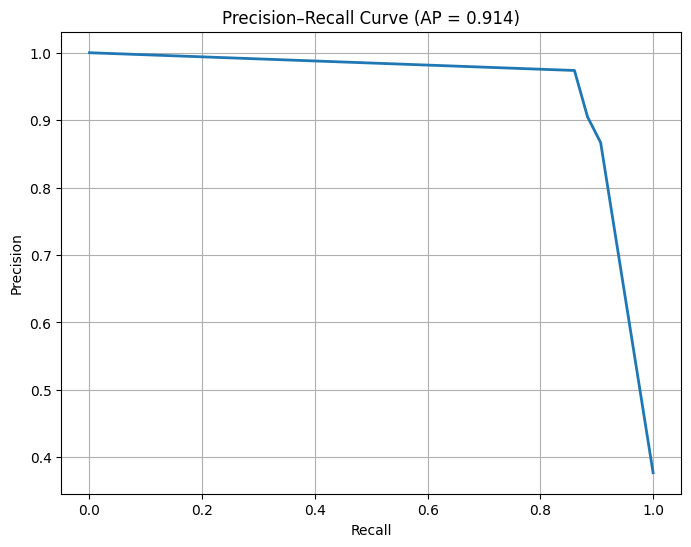

In [19]:
y_scores = decsion_tree_best.predict_proba(X_valid)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_valid, y_scores)
avg_precision = average_precision_score(y_valid, y_scores)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, linewidth=2)
plt.title(f"Precision–Recall Curve (AP = {avg_precision:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

## Feature Importance


Top 5 Important Features:
perimeter_worst         0.798816
concave points_worst    0.154142
texture_worst           0.024465
area_se                 0.022577
perimeter_mean          0.000000
dtype: float64


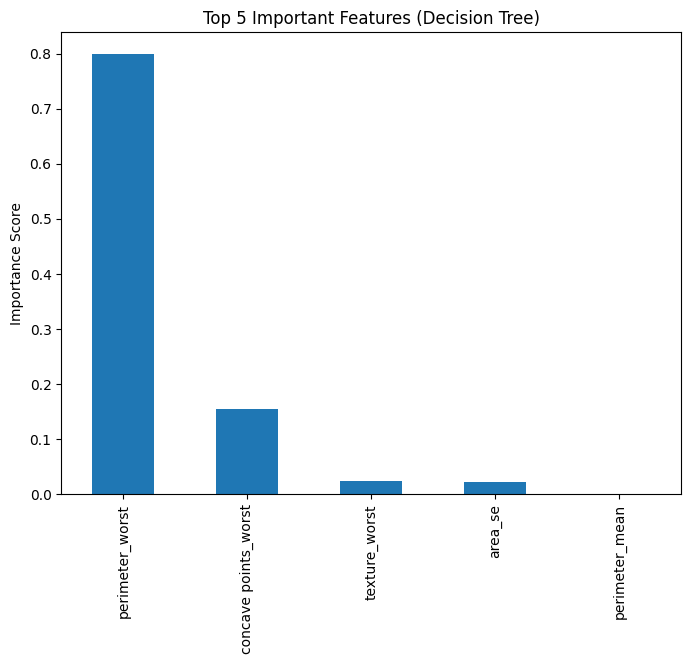

In [20]:
# Feature importance for the best decision tree model
importances = pd.Series(decsion_tree_best.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print("\nTop 5 Important Features:")
print(importances.head(5))

plt.figure(figsize=(8,6))
importances.head(5).plot(kind='bar')
plt.title("Top 5 Important Features (Decision Tree)")
plt.ylabel("Importance Score")
plt.show()

## Identifying misclassified data

In [21]:
valid_preds = decsion_tree_best.predict(X_valid)
misclassified_idx = (valid_preds != y_valid)

misclassified_samples = X_valid[misclassified_idx]
misclassified_true_labels = y_valid[misclassified_idx]
misclassified_pred_labels = valid_preds[misclassified_idx]

print("\nNumber of misclassified samples:", misclassified_samples.shape[0])

mis_df = pd.DataFrame(misclassified_samples)
mis_df["True Label"] = misclassified_true_labels
mis_df["Predicted"] = misclassified_pred_labels
print("\nMisclassified examples:\n")
print(mis_df.head())


Number of misclassified samples: 7

Misclassified examples:

     radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
86         14.48         21.46           94.25      648.2          0.09444   
263        15.61         19.38          100.00      758.6          0.07840   
5          12.45         15.70           82.57      477.1          0.12780   
91         15.37         22.76          100.20      728.2          0.09200   
440        10.97         17.20           71.73      371.5          0.08915   

     compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
86            0.09947         0.12040              0.04938         0.2075   
263           0.05616         0.04209              0.02847         0.1547   
5             0.17000         0.15780              0.08089         0.2087   
91            0.10360         0.11220              0.07483         0.1717   
440           0.11130         0.09457              0.03613         0.1489   

     f

In [22]:
# Comparing misclassified data with correctly classified data

correct_M = X_valid[(valid_preds == y_valid) & (y_valid == 1)]
correct_B = X_valid[(valid_preds == y_valid) & (y_valid == 0)]

print("\nAverage of correctly classified malignant samples:")
print(correct_M.mean().head())

print("\nAverage of misclassified malignant samples:")
print(mis_df[mis_df["True Label"] == 1].drop(columns=["True Label", "Predicted"]).mean().head())

print("\nAverage of correctly classified benign samples:")
print(correct_B.mean().head())

print("\nAverage of misclassified benign samples:")
print(mis_df[mis_df["True Label"] == 0].drop(columns=["True Label", "Predicted"]).mean().head())


Average of correctly classified malignant samples:
radius_mean          18.688919
texture_mean         21.681081
perimeter_mean      124.243784
area_mean          1118.537838
smoothness_mean       0.103489
dtype: float64

Average of misclassified malignant samples:
radius_mean         14.411667
texture_mean        19.940000
perimeter_mean      93.736667
area_mean          646.533333
smoothness_mean      0.098177
dtype: float64

Average of correctly classified benign samples:
radius_mean         11.876329
texture_mean        16.766429
perimeter_mean      76.285143
area_mean          441.681429
smoothness_mean      0.093177
dtype: float64

Average of misclassified benign samples:
radius_mean         10.97000
texture_mean        17.20000
perimeter_mean      71.73000
area_mean          371.50000
smoothness_mean      0.08915
dtype: float64


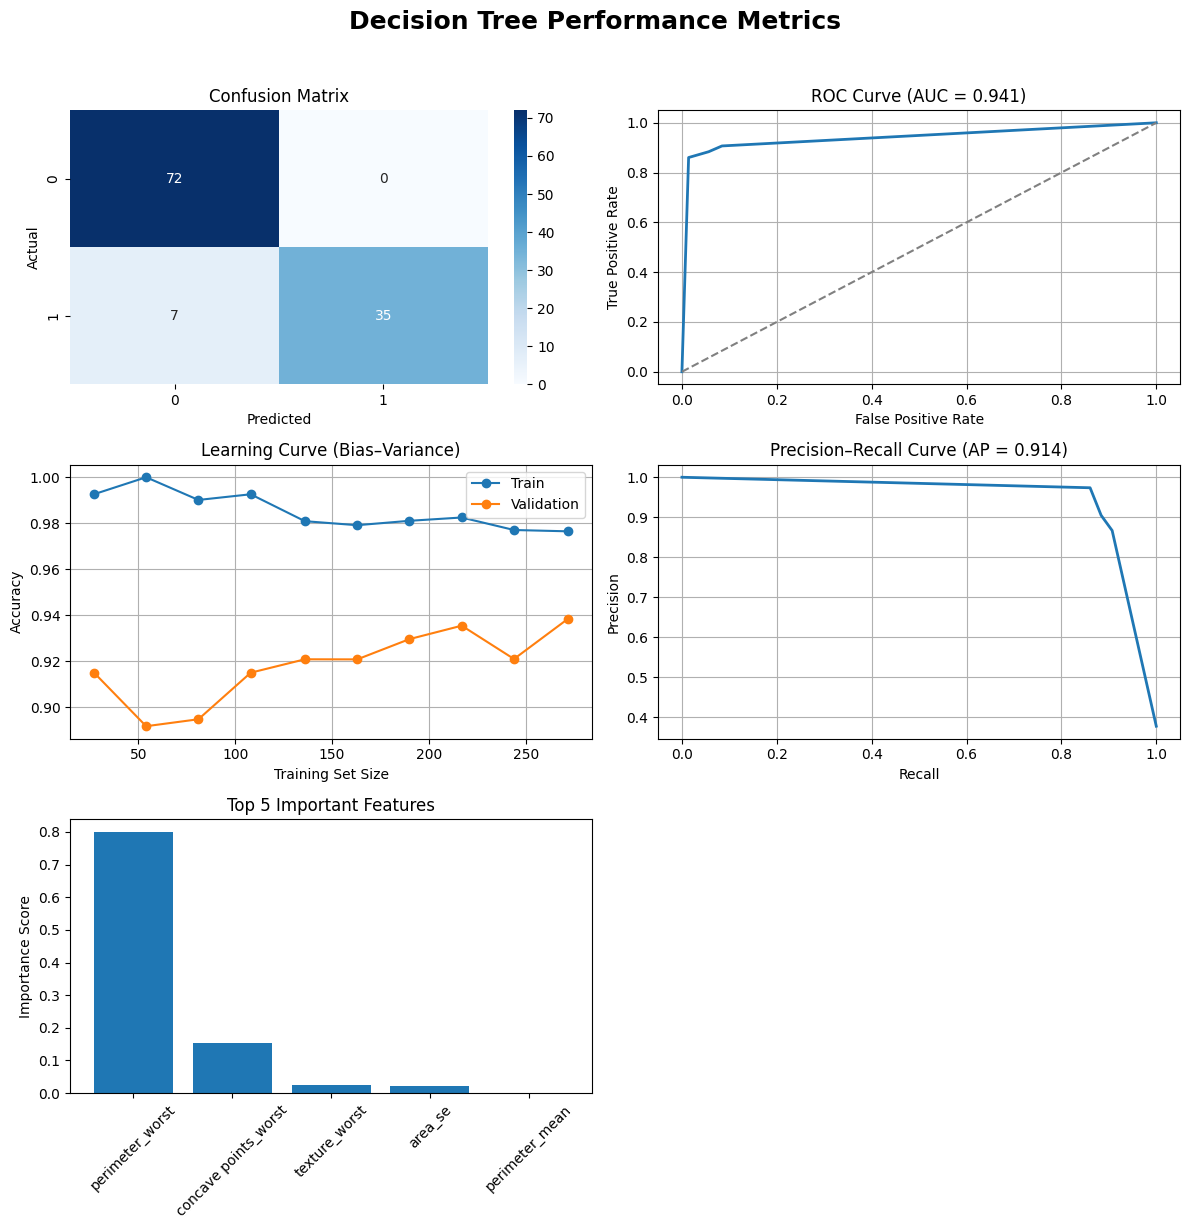

In [24]:
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report, 
                             confusion_matrix, roc_curve, precision_recall_curve, 
                             average_precision_score)
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

fig.suptitle("Decision Tree Performance Metrics", fontsize=18, fontweight='bold', y=1.02)

y_pred = decsion_tree_best.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

y_prob = decsion_tree_best.predict_proba(X_valid)[:, 1]
fpr, tpr, _ = roc_curve(y_valid, y_prob)
auc = roc_auc_score(y_valid, y_prob)

axes[1].plot(fpr, tpr, linewidth=2)
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_title(f"ROC Curve (AUC = {auc:.3f})")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].grid(True)

train_sizes, train_scores, valid_scores = learning_curve(
    decsion_tree_best, X_train, y_train, cv=5, scoring='accuracy',
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

axes[2].plot(train_sizes, train_mean, 'o-', label="Train")
axes[2].plot(train_sizes, valid_mean, 'o-', label="Validation")
axes[2].set_title("Learning Curve (Bias–Variance)")
axes[2].set_xlabel("Training Set Size")
axes[2].set_ylabel("Accuracy")
axes[2].legend()
axes[2].grid(True)

precision, recall, thresholds = precision_recall_curve(y_valid, y_prob)
avg_precision = average_precision_score(y_valid, y_prob)

axes[3].plot(recall, precision, linewidth=2)
axes[3].set_title(f"Precision–Recall Curve (AP = {avg_precision:.3f})")
axes[3].set_xlabel("Recall")
axes[3].set_ylabel("Precision")
axes[3].grid(True)


importances = pd.Series(decsion_tree_best.feature_importances_, index=X_train.columns)
top5 = importances.sort_values(ascending=False).head(5)

axes[4].bar(top5.index, top5.values)
axes[4].set_title("Top 5 Important Features")
axes[4].set_ylabel("Importance Score")
axes[4].tick_params(axis='x', rotation=45)

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()
